# Vietnam House-Price Prediction

Standalone regression project for estimating Vietnamese house prices from property characteristics.

## Vietnam house-price project

This notebook transforms raw property listings into a mixed numerical/categorical feature matrix, compares regression algorithms, and persists the selected pipeline for the web application.

## 1. Imports and reproducibility

In [1]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
print('Working directory:', os.getcwd())

Working directory: e:\jupyter project\.repos\housing


## 2. Load listings and define the prediction target

The target is `Price`, measured in billion VND. `Address` is reduced to a city/province feature because the complete free-text address is too sparse and too specific for this first model.

In [3]:
housing = pd.read_csv('vietnam_housing_dataset.csv')
housing['City'] = housing['Address'].fillna('Unknown').str.split(',').str[-1].str.strip().str.rstrip('.')
housing = housing.drop_duplicates().copy()

HOUSE_NUMERIC_FEATURES = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
HOUSE_CATEGORICAL_FEATURES = ['City', 'House direction', 'Balcony direction', 'Legal status', 'Furniture state']
HOUSE_TARGET = 'Price'
housing_model = housing[HOUSE_NUMERIC_FEATURES + HOUSE_CATEGORICAL_FEATURES + [HOUSE_TARGET]].dropna(subset=[HOUSE_TARGET])
print('Rows and columns:', housing_model.shape)
display(housing_model.head())

Rows and columns: (30229, 12)


,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,City,House direction,Balcony direction,Legal status,Furniture state,Price
0,84.0,NaN,NaN,4.0,NaN,NaN,Hưng Yên,NaN,NaN,Have certificate,NaN,8.60
1,60.0,NaN,NaN,5.0,NaN,NaN,Hưng Yên,NaN,NaN,NaN,NaN,7.50
2,90.0,6.0,13.0,5.0,NaN,NaN,Hưng Yên,Đông - Bắc,Đông - Bắc,Sale contract,NaN,8.90
3,54.0,NaN,3.5,2.0,2.0,3.0,Hồ Chí Minh,Tây - Nam,Tây - Nam,Have certificate,Full,5.35
4,92.0,NaN,NaN,2.0,4.0,4.0,Hồ Chí Minh,Đông - Nam,Đông - Nam,Have certificate,Full,6.90


## 3. Data quality and useful visual evidence

These plots answer practical questions: how skewed are prices and areas, which cities dominate the sample, and whether area is visibly related to price. They guide metric choice and motivate retaining location in the representation.

Duplicate rows: 0
Missing target rows: 0


,count,mean,std,min,25%,50%,75%,max
Area,30229.0,68.50,48.07,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,5.36,4.35,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,7.85,7.45,1.0,4.0,6.0,10.0,85.0
Floors,26626.0,3.41,1.33,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,3.51,1.31,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,3.35,1.40,1.0,2.0,3.0,4.0,9.0
Price,30229.0,5.87,2.21,1.0,4.2,5.9,7.5,11.5


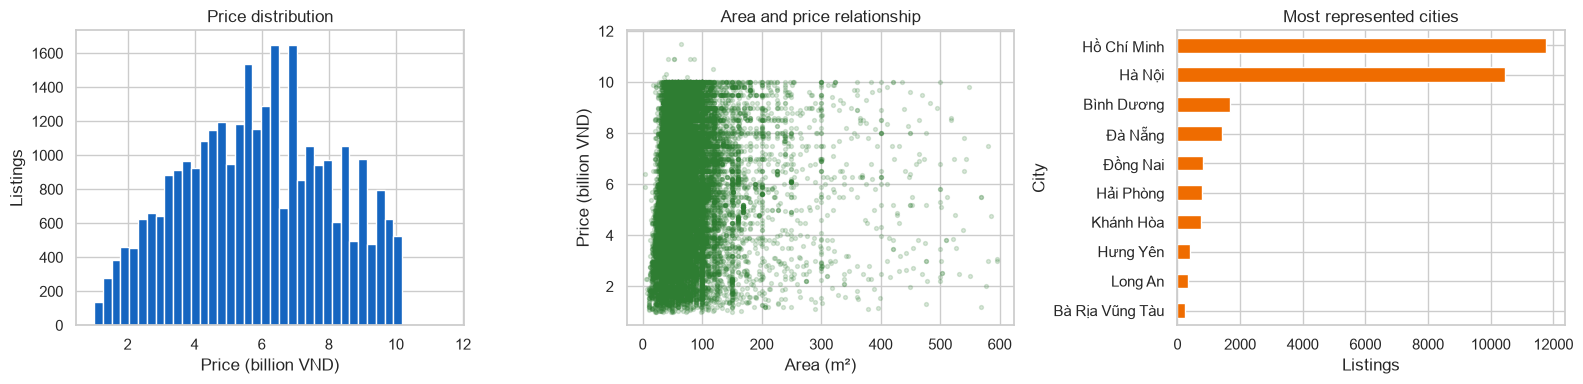

In [4]:
print('Duplicate rows:', housing.duplicated().sum())
print('Missing target rows:', housing['Price'].isna().sum())
display(housing_model[HOUSE_NUMERIC_FEATURES + [HOUSE_TARGET]].describe().T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(housing_model['Price'], bins=40, color='#1565c0', edgecolor='white')
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price (billion VND)')
axes[0].set_ylabel('Listings')
axes[1].scatter(housing_model['Area'], housing_model['Price'], alpha=0.18, s=8, color='#2e7d32')
axes[1].set_title('Area and price relationship')
axes[1].set_xlabel('Area (m²)')
axes[1].set_ylabel('Price (billion VND)')
city_counts = housing_model['City'].value_counts().head(10).sort_values()
city_counts.plot(kind='barh', ax=axes[2], color='#ef6c00')
axes[2].set_title('Most represented cities')
axes[2].set_xlabel('Listings')
plt.tight_layout()
plt.show()

## 4. Split data and build a leakage-safe preprocessing pipeline

Numerical variables are median-imputed and standardized. Categorical variables are mode-imputed and one-hot encoded. Fitting these transformations only on the training split prevents information from the test set leaking into training.

In [5]:
X_house = housing_model[HOUSE_NUMERIC_FEATURES + HOUSE_CATEGORICAL_FEATURES]
y_house = housing_model[HOUSE_TARGET]
X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(
    X_house, y_house, test_size=0.20, random_state=RANDOM_STATE
)

house_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
house_categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
house_preprocessor = ColumnTransformer([
    ('numeric', house_numeric_pipeline, HOUSE_NUMERIC_FEATURES),
    ('categorical', house_categorical_pipeline, HOUSE_CATEGORICAL_FEATURES),
])
print('Raw feature matrix:', X_house.shape)
print('Training/test shapes:', X_house_train.shape, X_house_test.shape)

Raw feature matrix: (30229, 11)
Training/test shapes: (24183, 11) (6046, 11)


## 5. Train regression models

Linear Regression is an interpretable baseline, Ridge stabilizes correlated one-hot features, Gradient Boosting captures nonlinear residual patterns, and Random Forest captures nonlinear interactions robustly.

In [6]:
house_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=18, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE),
}
house_pipelines = {}
for name, estimator in house_models.items():
    house_pipelines[name] = Pipeline([
        ('preprocessor', house_preprocessor),
        ('model', estimator),
    ])
    house_pipelines[name].fit(X_house_train, y_house_train)
print('Trained:', ', '.join(house_pipelines))

Trained: Linear Regression, Ridge Regression, Random Forest, Gradient Boosting


## 6. Evaluate models and select a candidate

MAE is easy to interpret in billion VND, RMSE penalizes large pricing errors, and $R^2$ measures explained variation. We use the same held-out test set for every model.

,MAE,RMSE,R2
Model,,,
Random Forest,1.2275,1.5964,0.4773
Gradient Boosting,1.2779,1.6173,0.4635
Linear Regression,1.4491,1.8102,0.3280
Ridge Regression,1.4515,1.8121,0.3266


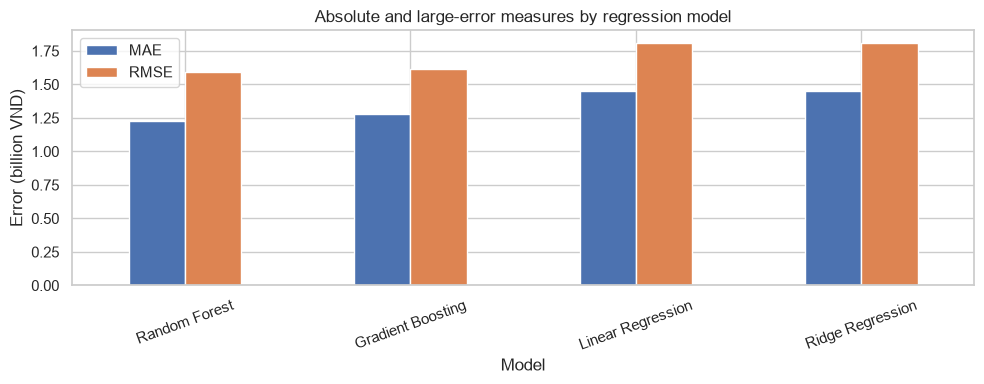

Selected model by RMSE: Random Forest


In [7]:
house_rows = []
for name, pipeline in house_pipelines.items():
    prediction = pipeline.predict(X_house_test)
    house_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_house_test, prediction),
        'RMSE': mean_squared_error(y_house_test, prediction) ** 0.5,
        'R2': r2_score(y_house_test, prediction),
    })
house_results = pd.DataFrame(house_rows).set_index('Model').sort_values('RMSE')
display(house_results.round(4))

house_results[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 4), rot=20)
plt.title('Absolute and large-error measures by regression model')
plt.ylabel('Error (billion VND)')
plt.tight_layout()
plt.show()

house_best_name = house_results.index[0]
house_best_pipeline = house_pipelines[house_best_name]
print('Selected model by RMSE:', house_best_name)

## 7. Test whether location representation helps

,Representation,RMSE
0,With City,1.5964
1,Without City,1.8305


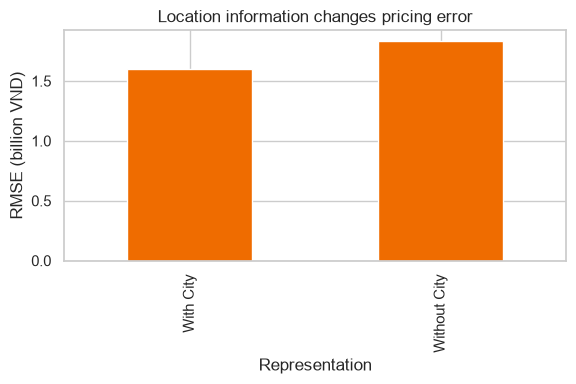

In [8]:
no_city_features = HOUSE_NUMERIC_FEATURES + [feature for feature in HOUSE_CATEGORICAL_FEATURES if feature != 'City']
no_city_preprocessor = ColumnTransformer([
    ('numeric', house_numeric_pipeline, HOUSE_NUMERIC_FEATURES),
    ('categorical', house_categorical_pipeline, [feature for feature in HOUSE_CATEGORICAL_FEATURES if feature != 'City']),
])
no_city_pipeline = Pipeline([
    ('preprocessor', no_city_preprocessor),
    ('model', RandomForestRegressor(n_estimators=150, max_depth=18, random_state=RANDOM_STATE, n_jobs=-1)),
])
no_city_pipeline.fit(X_house_train[no_city_features], y_house_train)
city_experiment = pd.DataFrame({
    'Representation': ['With City', 'Without City'],
    'RMSE': [
        mean_squared_error(y_house_test, house_best_pipeline.predict(X_house_test)) ** 0.5,
        mean_squared_error(y_house_test, no_city_pipeline.predict(X_house_test[no_city_features])) ** 0.5,
    ],
})
display(city_experiment.round(4))
city_experiment.plot(x='Representation', y='RMSE', kind='bar', legend=False, figsize=(6, 4), color='#ef6c00')
plt.title('Location information changes pricing error')
plt.ylabel('RMSE (billion VND)')
plt.tight_layout()
plt.show()

## 8. Persist the selected pipeline and test one listing

In [9]:
with open('house_price_model.sav', 'wb') as file:
    pickle.dump(house_best_pipeline, file)
print('Saved house_price_model.sav')

house_sample = X_house_test.iloc[[0]]
display(house_sample)
print('Actual price:', round(float(y_house_test.iloc[0]), 3), 'billion VND')
print('Predicted price:', round(float(house_best_pipeline.predict(house_sample)[0]), 3), 'billion VND')

Saved house_price_model.sav


,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,City,House direction,Balcony direction,Legal status,Furniture state
23170,82.0,NaN,NaN,2.0,3.0,3.0,Hồ Chí Minh,NaN,NaN,Have certificate,NaN


Actual price: 8.3 billion VND
Predicted price: 7.549 billion VND
